In [ ]:
"""
=============================================================================
  PROJET : Analyse Démographique - Région de Tanger
  ORGANISME : Haut-Commissariat au Plan (HCP) - Direction Régionale
  PHASE CRISP-DM : Data Preparation (Phase 2)
  SCRIPT : Nettoyage & Préparation des Données RGPH
  OUTPUT : population_preparee_finale.csv
=============================================================================


"""

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION GLOBALE
# ─────────────────────────────────────────────────────────────────────────────

INPUT_FILE  = "indicateur_population.csv"
OUTPUT_FILE = "population_preparee_finale.csv"

ANNEE_DEBUT = 2004
ANNEE_FIN   = 2024
ANNEES_RGPH = [2004, 2014, 2024]

# Colonne de strate géographique supérieure pour le TCAM de référence
COL_STRATE_REF = "province"        # ← Adapter si besoin

# TCAM de repli global si la strate elle-même n'a aucune donnée valide (%)
TCAM_REPLI_GLOBAL = 2.5            # ← Taux régional Tanger-Tétouan-Al Hoceima

# ★ FIX : seuil minimal de cohérence du TCAM calculé (en valeur absolue, %)
# Si le TCAM médian observé est inférieur à ce seuil, on bascule sur
# TCAM_REPLI_GLOBAL pour éviter les séries quasi-plates sur micro-communes.
# Raisonnement : un TCAM de ±0.05%/an ne produit aucun effet visible après
# arrondi sur des communes < 5 000 habitants.
TCAM_MIN_COHERENT = 0.05           # 0.05 % / an — seuil de cohérence

# ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 0 : BANNIÈRE DE DÉMARRAGE
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 70)
print("  HCP - NETTOYAGE DES DONNÉES DÉMOGRAPHIQUES - RÉGION TANGER")
print("  Pipeline CRISP-DM — 7 Étapes  |  v2 (fix biais discrétisation)")
print("=" * 70)

# ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 1 : INGESTION SÉCURISÉE
# ─────────────────────────────────────────────────────────────────────────────

print("\n[ÉTAPE 1] Ingestion sécurisée du fichier source...")

encodings_a_essayer = ["utf-8", "utf-8-sig", "latin-1", "cp1252"]
separateurs         = [";", ",", "\t"]

df_raw = None
for enc in encodings_a_essayer:
    for sep in separateurs:
        try:
            df_raw = pd.read_csv(
                INPUT_FILE,
                encoding=enc,
                sep=sep,
                decimal=",",
                thousands=" ",
                low_memory=False
            )
            if df_raw.shape[1] > 1:
                print(f"  ✅ Lecture réussie → encoding='{enc}', sep='{sep}'")
                break
        except Exception:
            continue
    if df_raw is not None and df_raw.shape[1] > 1:
        break

if df_raw is None or df_raw.shape[1] <= 1:
    raise ValueError(
        "❌ Impossible de lire le fichier. "
        "Vérifiez le chemin, l'encodage ou le séparateur."
    )

print(f"  → Dimensions brutes : {df_raw.shape[0]} lignes × {df_raw.shape[1]} colonnes")
print(f"  → Colonnes brutes   : {list(df_raw.columns)}")

# ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 2 : STANDARDISATION DES EN-TÊTES
# ─────────────────────────────────────────────────────────────────────────────

print("\n[ÉTAPE 2] Standardisation des en-têtes...")

df = df_raw.copy()

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"\s+",         "_",  regex=True)
    .str.replace(r"[éèê]",       "e",  regex=True)
    .str.replace(r"[àâ]",        "a",  regex=True)
    .str.replace(r"[îï]",        "i",  regex=True)
    .str.replace(r"[ôö]",        "o",  regex=True)
    .str.replace(r"[ùûü]",       "u",  regex=True)
    .str.replace(r"[^a-z0-9_]",  "",   regex=True)
)

print(f"  ✅ Colonnes standardisées : {list(df.columns)}")

# Détection automatique des colonnes population
pop_cols = [c for c in df.columns
            if c.startswith("pop") or
            any(str(a) in c for a in range(2000, 2030))]

if not pop_cols:
    pop_cols = [c for c in df.columns
                if c.isdigit() and 2000 <= int(c) <= 2030]

id_cols_detectees = [c for c in df.columns if c not in pop_cols]
print(f"  → Colonnes population : {pop_cols}")
print(f"  → Colonnes identité   : {id_cols_detectees}")

# ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 3 : TRAITEMENT DES ZÉROS ABERRANTS
# ─────────────────────────────────────────────────────────────────────────────

print("\n[ÉTAPE 3] Traitement des zéros aberrants...")

nb_zeros_avant = (df[pop_cols] == 0).sum().sum()
df[pop_cols]   = df[pop_cols].replace(0, np.nan)

for col in pop_cols:
    if pd.api.types.is_numeric_dtype(df[col]):
        df.loc[df[col] < 0, col] = np.nan

nb_zeros_apres = (df[pop_cols] == 0).sum().sum()
print(f"  ✅ {nb_zeros_avant} zéro(s) → NaN  ({nb_zeros_apres} restant(s))")

# ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 4 : NETTOYAGE DES ESPACES MILLIERS
# ─────────────────────────────────────────────────────────────────────────────

print("\n[ÉTAPE 4] Conversion numérique des colonnes population...")

def nettoyer_et_convertir(series):
    """Nettoie une colonne texte avec espaces milliers → float."""
    if series.dtype == object:
        series = (
            series
            .astype(str)
            .str.strip()
            .str.replace("\u202f", "", regex=False)  # Espace fine insécable
            .str.replace("\xa0",   "", regex=False)  # Espace insécable HTML
            .str.replace(" ",      "", regex=False)  # Espace normal
            .str.replace(",",      ".", regex=False)  # Décimale FR → EN
            .replace("nan", np.nan)
            .replace("",    np.nan)
        )
        return pd.to_numeric(series, errors="coerce")
    return pd.to_numeric(series, errors="coerce")

for col in pop_cols:
    df[col] = nettoyer_et_convertir(df[col])

print(f"  ✅ {len(pop_cols)} colonne(s) converties en float64")
print(f"  → Types : {df[pop_cols].dtypes.unique()}")

# ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 5 : RECONSTRUCTION INTERCENSITAIRE PAR INTERPOLATION LINÉAIRE
# ─────────────────────────────────────────────────────────────────────────────

print("\n[ÉTAPE 5] Interpolation linéaire intercensitaire (2004 → 2024)...")

def extraire_annee(col_name):
    """Extrait l'année depuis un nom de colonne type 'pop_2014'."""
    for token in col_name.split("_"):
        if token.isdigit() and 2000 <= int(token) <= 2030:
            return int(token)
    return None

annees_pop       = [extraire_annee(c) for c in pop_cols]
annees_pop_valid = [(a, c) for a, c in zip(annees_pop, pop_cols) if a is not None]
annees_pop_valid.sort(key=lambda x: x[0])

if not annees_pop_valid:
    annees_pop_valid = [(int(c), c) for c in pop_cols
                        if c.isdigit() and 2000 <= int(c) <= 2030]
    annees_pop_valid.sort()

print(f"  → Années identifiées : {[a for a, _ in annees_pop_valid]}")

annees_serie   = list(range(ANNEE_DEBUT, ANNEE_FIN + 1))
annees_col_map = {a: c for a, c in annees_pop_valid}

# Créer les colonnes des années manquantes (remplies de NaN)
for annee in [a for a in annees_serie if a not in annees_col_map]:
    df[str(annee)]        = np.nan
    annees_col_map[annee] = str(annee)

# Renommer vers le format unifié "pop_XXXX"
rename_map = {}
for annee, old_col in annees_col_map.items():
    new_col = f"pop_{annee}"
    if old_col != new_col and old_col in df.columns:
        rename_map[old_col] = new_col

df.rename(columns=rename_map, inplace=True)

pop_cols_finales = [f"pop_{a}" for a in annees_serie]
for col in pop_cols_finales:
    if col not in df.columns:
        df[col] = np.nan

# Interpolation ligne par ligne via transposition — résultat en float64
print("  → Application de l'interpolation linéaire par commune...")
df_pop_T        = df[pop_cols_finales].T
df_pop_T_interp = df_pop_T.interpolate(
    method="linear", axis=0, limit_direction="both"
)
df[pop_cols_finales] = df_pop_T_interp.T

print(f"  ✅ Interpolation terminée — NaN restants : "
      f"{df[pop_cols_finales].isna().sum().sum()}")

# ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 6 : EXTRAPOLATION & FORMATAGE INTERMÉDIAIRE (bfill / ffill)
# ─────────────────────────────────────────────────────────────────────────────

print("\n[ÉTAPE 6] Extrapolation des valeurs extrêmes (bfill / ffill)...")

df[pop_cols_finales] = df[pop_cols_finales].bfill(axis=1)
df[pop_cols_finales] = df[pop_cols_finales].ffill(axis=1)

# ★ AUCUN .round() ni .astype(int) ici — on reste en float64 jusqu'à la fin
nb_nan_e6 = df[pop_cols_finales].isna().sum().sum()
print(f"  ✅ bfill + ffill appliqués — NaN résiduels : {nb_nan_e6}")
print(f"  → Colonnes maintenues en float64 (arrondi différé à la fin du pipeline)")

# ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 7 : ★ CORRECTION DU BIAIS D'IMPUTATION CONSTANTE
#              Dynamisation des Séries Uniques par TCAM de Référence
# ─────────────────────────────────────────────────────────────────────────────


print("\n[ÉTAPE 7] ★ Correction du biais d'imputation constante...")
print("─" * 70)

# ── 7.A  IDENTIFICATION DES COMMUNES À SÉRIE CONSTANTE ──────────────────────
# ★ FIX : on évalue la variance sur float64 pur — jamais sur des entiers

print("  [7.A] Identification des communes à population constante...")

# S'assurer que tout est float64 avant la détection (jamais Int64 ici)
df_pop_float    = df[pop_cols_finales].astype(float)
variance_ligne  = df_pop_float.var(axis=1)    # Variance sur l'axe temporel
masque_constant = variance_ligne == 0         # True = série totalement plate

nb_total    = len(df)
nb_constant = masque_constant.sum()

print(f"  → Communes scannées        : {nb_total}")
print(f"  → Communes à série plate   : {nb_constant} "
      f"({nb_constant / nb_total * 100:.1f}%)")
print(f"  → Communes avec dynamique  : {nb_total - nb_constant} "
      f"({(nb_total - nb_constant) / nb_total * 100:.1f}%)")

if nb_constant == 0:
    print("\n  ✅ Aucun biais détecté — étape 7 sans effet.")

else:
    # ── 7.B  CALCUL DU TCAM DE RÉFÉRENCE PAR STRATE ─────────────────────────

    print(f"\n  [7.B] Calcul du TCAM de référence par '{COL_STRATE_REF}'...")

    # Résolution du nom de colonne strate après standardisation
    strate_col = COL_STRATE_REF
    if strate_col not in df.columns:
        candidats  = [c for c in df.columns if COL_STRATE_REF in c]
        strate_col = candidats[0] if candidats else None
        if strate_col:
            print(f"  ⚠️  Colonne strate résolue en '{strate_col}'")
        else:
            print(f"  ⚠️  Colonne '{COL_STRATE_REF}' introuvable → repli global")

    # TCAM individuel pour chaque commune NON-constante
    def tcam_ligne(row):
        """
        TCAM entre la première et la dernière valeur non-NaN de la série.
        Formule : r = (P_fin / P_deb)^(1/n) − 1
        """
        vals   = row.dropna()
        annees = [int(c.split("_")[1]) for c in vals.index]
        if len(vals) < 2 or vals.iloc[0] <= 0:
            return np.nan
        n = annees[-1] - annees[0]
        if n == 0:
            return np.nan
        return (vals.iloc[-1] / vals.iloc[0]) ** (1 / n) - 1

    df_fiables   = df_pop_float.loc[~masque_constant]
    tcam_fiables = df_fiables.apply(tcam_ligne, axis=1)   # Série de TCAM (décimal)

    # Agrégation médiane par strate (robuste aux outliers)
    tcam_par_strate = {}
    if strate_col and strate_col in df.columns:
        strates_fiables = df.loc[~masque_constant, strate_col].values
        df_tcam_strate  = pd.DataFrame({
            "tcam"   : tcam_fiables.values,
            "strate" : strates_fiables
        }).dropna(subset=["tcam"])

        tcam_par_strate = (
            df_tcam_strate
            .groupby("strate")["tcam"]
            .median()
            .to_dict()
        )

        print(f"  → TCAM médian calculé pour {len(tcam_par_strate)} strate(s) :")
        for strate, taux in sorted(tcam_par_strate.items()):
            n_communes = (df.loc[~masque_constant, strate_col] == strate).sum()
            print(f"       {str(strate):<30} : {taux*100:+.3f}% / an  "
                  f"(basé sur {n_communes} commune(s))")

    # ★ FIX 7.B — TCAM médian global avec garde-fou de cohérence
    # ─────────────────────────────────────────────────────────────
    # Le TCAM médian observé peut être aberrant (ex: -0.013%) si la majorité
    # des communes du dataset sont en légère décroissance. Ce taux est trop
    # faible pour produire un incrément visible après arrondi sur des
    # micro-communes. On lui substitue TCAM_REPLI_GLOBAL dans ce cas.
    valeurs_tcam_valides = tcam_fiables.dropna()
    tcam_calcule = (
        valeurs_tcam_valides.median()
        if not valeurs_tcam_valides.empty
        else TCAM_REPLI_GLOBAL / 100
    )

    if abs(tcam_calcule) * 100 < TCAM_MIN_COHERENT:
        print(f"\n  ⚠️  TCAM médian calculé ({tcam_calcule*100:+.4f}%) < seuil de cohérence"
              f" ({TCAM_MIN_COHERENT:.2f}%)")
        print(f"  ★  Bascule sur TCAM_REPLI_GLOBAL = {TCAM_REPLI_GLOBAL:+.3f}% / an")
        tcam_global = TCAM_REPLI_GLOBAL / 100
    else:
        tcam_global = tcam_calcule
        print(f"  ✅ TCAM médian global retenu : {tcam_global*100:+.3f}% / an")

    print(f"\n  → TCAM de repli effectif : {tcam_global*100:+.3f}% / an")

    # ★ FIX 7.B (suite) — cohérence des TCAM par strate
    # Si un TCAM de strate est également inférieur au seuil, on le remplace
    # par tcam_global (qui est déjà lui-même cohérent à ce stade).
    tcam_par_strate_corrige = {}
    for strate, taux in tcam_par_strate.items():
        if abs(taux) * 100 < TCAM_MIN_COHERENT:
            print(f"  ⚠️  Strate '{strate}' : TCAM={taux*100:+.4f}% → remplacé par repli global")
            tcam_par_strate_corrige[strate] = tcam_global
        else:
            tcam_par_strate_corrige[strate] = taux

    # ── 7.C  DYNAMISATION PAR INTÉRÊTS COMPOSÉS ──────────────────────────────
    #         Pₙ = P₀ × (1 + r)ⁿ
    #
    
    print(f"\n  [7.C] Dynamisation par intérêts composés : Pₙ = P₀ × (1 + r)ⁿ")
    print(f"  → Toutes les opérations maintenues en float64 (arrondi différé)")
    print(f"  → Traitement de {nb_constant} commune(s)...")

    annees_serie_int  = [int(c.split("_")[1]) for c in pop_cols_finales]
    compteur_dynamise = 0
    log_echecs        = []

    for idx in df.index[masque_constant]:

        # ── Valeur pivot P₀ : valeur plate héritée du fill (= seule valeur connue)
        p0 = df_pop_float.loc[idx, "pop_2004"]    # Même valeur sur toute la ligne
        if pd.isna(p0) or p0 <= 0:
            log_echecs.append(idx)
            continue                               # Aucune valeur → on laisse

        # ── Sélection du TCAM : strate corrigée → global
        r = tcam_global
        if strate_col and strate_col in df.columns:
            strate_val = df.loc[idx, strate_col]
            r = tcam_par_strate_corrige.get(strate_val, tcam_global)

        # ── Application de la formule des intérêts composés pour chaque année
        #    P₀ est ancré en ANNEE_DEBUT (2004), n = année_cible − 2004
        #    Résultat : float64 précis, SANS arrondi intermédiaire
        nouvelles_valeurs = {
            col: float(p0) * ((1.0 + r) ** (annee - ANNEE_DEBUT))
            for col, annee in zip(pop_cols_finales, annees_serie_int)
        }

        # Écriture dans le DataFrame : on reste en float64
        df.loc[idx, pop_cols_finales] = pd.Series(nouvelles_valeurs, dtype=float)
        compteur_dynamise += 1

    if log_echecs:
        print(f"\n  ⚠️  {len(log_echecs)} commune(s) non-dynamisables "
              f"(aucune valeur P₀ disponible) — conservées telles quelles.")

    # ── 7.D  VÉRIFICATION POST-CORRECTION ────────────────────────────────────

    print(f"\n  [7.D] Vérification post-correction...")

    # ★ FIX 7.D : vérification sur float64 (avant arrondi) → le test est juste
    variance_post   = df[pop_cols_finales].astype(float).var(axis=1)
    encore_constant = (variance_post == 0).sum()

    print(f"  → Communes dynamisées avec succès : {compteur_dynamise}")
    print(f"  → Communes encore constantes      : {encore_constant}")

    if encore_constant > 0:
        print(f"  ⚠️  Ces communes n'avaient aucune valeur P₀ exploitable.")

    # Validation : TCAM post-dynamisation et incrément minimal
    if compteur_dynamise > 0:
        tcam_post = df.loc[masque_constant, pop_cols_finales].astype(float).apply(
            tcam_ligne, axis=1
        ).dropna()
        if not tcam_post.empty:
            print(f"\n  → TCAM post-dynamisation (communes corrigées) :")
            print(f"       Min    : {tcam_post.min()*100:+.3f}%")
            print(f"       Médian : {tcam_post.median()*100:+.3f}%")
            print(f"       Max    : {tcam_post.max()*100:+.3f}%")

        # ★ Diagnostic de discrétisation : incrément annuel minimal attendu
        print(f"\n  → Diagnostic discrétisation (TCAM={tcam_global*100:+.4f}%/an) :")
        communes_fix = df.loc[masque_constant].copy()
        for idx in communes_fix.index:
            p0_val     = float(df_pop_float.loc[idx, "pop_2004"])
            delta_1an  = p0_val * abs(tcam_global)            # Incrément brut (float)
            zone_name  = df.loc[idx, "zone_geographique"] if "zone_geographique" in df.columns else str(idx)
            flag_ok    = "✅" if delta_1an >= 0.5 else "⚠️ "
            print(f"       {flag_ok} {str(zone_name):<35} "
                  f"P₀={p0_val:>8.0f}  δ/an={delta_1an:>6.2f} hab")

    # ── Rapport de synthèse Étape 7 ──────────────────────────────────────────
    print()
    print("  ┌─ Rapport Étape 7 " + "─" * 50 + "┐")
    print(f"  │  Problème détecté      : {nb_constant} communes à variance nulle (TCAM=0%)   │")
    print(f"  │  Formule appliquée     : Pₙ = P₀ × (1 + r)ⁿ  (float64, no round)   │")
    print(f"  │  Strate de référence   : {str(strate_col):<45} │")
    print(f"  │  TCAM effectif (repli) : {tcam_global*100:+.4f}% / an                        │")
    print(f"  │  Seuil cohérence       : ±{TCAM_MIN_COHERENT:.2f}% / an                             │")
    print(f"  │  Communes dynamisées   : {compteur_dynamise:<45} │")
    print(f"  │  Communes résiduelles  : {encore_constant:<45} │")
    print("  └" + "─" * 68 + "┘")

# ─────────────────────────────────────────────────────────────────────────────
# FORMATAGE FINAL (après Étape 7)
# ★ FIX : Un seul arrondi, ici, à la toute fin — jamais avant
# ─────────────────────────────────────────────────────────────────────────────

print("\n[FORMAT] Arrondissement et typage final des colonnes population...")
print("  → Arrondi appliqué une seule fois (fin de pipeline, après Étape 7)")

# Sécurité : clip des valeurs négatives (impossible démographiquement)
for col in pop_cols_finales:
    df[col] = pd.to_numeric(df[col], errors="coerce").clip(lower=0)

# Arrondi à l'entier puis conversion en Int64 (nullable integer)
# C'est le SEUL endroit dans tout le pipeline où l'on perd les décimales.
df[pop_cols_finales] = df[pop_cols_finales].round(0).astype("Int64")

print(f"  ✅ Typage Int64 appliqué — NaN résiduels : "
      f"{df[pop_cols_finales].isna().sum().sum()}")

# ─────────────────────────────────────────────────────────────────────────────
# INDICATEURS DÉRIVÉS (EDA & ML)
# ─────────────────────────────────────────────────────────────────────────────

print("\n[INDICATEURS] Calcul des métriques dérivées...")

# TCAM 2004→2024 (en %)
try:
    p_debut = df["pop_2004"].astype(float)
    p_fin   = df["pop_2024"].astype(float)
    df["tcam_2004_2024_pct"] = (
        ((p_fin / p_debut) ** (1 / 20) - 1) * 100
    ).round(4)
    print("  ✅ tcam_2004_2024_pct")
except Exception as e:
    print(f"  ⚠️  TCAM : {e}")

# Variation absolue 2014→2024
try:
    df["variation_abs_2014_2024"] = (
        df["pop_2024"].astype(float) - df["pop_2014"].astype(float)
    ).round(0).astype("Int64")
    print("  ✅ variation_abs_2014_2024")
except Exception as e:
    print(f"  ⚠️  Variation absolue : {e}")

# Flag qualité : 1 si la commune a été dynamisée à l'étape 7
if nb_constant > 0:
    df["flag_dynamise_e7"] = masque_constant.astype(int)
    print("  ✅ flag_dynamise_e7  (1 = corrigée à l'étape 7)")

# ─────────────────────────────────────────────────────────────────────────────
# RÉORGANISATION DES COLONNES
# ─────────────────────────────────────────────────────────────────────────────

cols_indicateurs = [
    "tcam_2004_2024_pct",
    "variation_abs_2014_2024",
    "flag_dynamise_e7"
]
cols_indicateurs = [c for c in cols_indicateurs if c in df.columns]
cols_id          = [c for c in df.columns
                    if c not in pop_cols_finales + cols_indicateurs]

df = df[cols_id + pop_cols_finales + cols_indicateurs]

# ─────────────────────────────────────────────────────────────────────────────
# EXPORT FINAL
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n[EXPORT] Sauvegarde → {OUTPUT_FILE}")

df.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig",    # BOM UTF-8 → compatible Excel francophone
    sep=";",
    decimal=","
)

print(f"  ✅ Fichier exporté.")

# ─────────────────────────────────────────────────────────────────────────────
# RAPPORT DE QUALITÉ FINAL
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 70)
print("  RAPPORT DE QUALITÉ — DONNÉES FINALES")
print("=" * 70)
print(f"  Fichier output        : {OUTPUT_FILE}")
print(f"  Dimensions            : {df.shape[0]} communes × {df.shape[1]} colonnes")
print(f"  Années couvertes      : {ANNEE_DEBUT} → {ANNEE_FIN} "
      f"({len(pop_cols_finales)} années)")
print(f"  NaN résiduels totaux  : {df.isna().sum().sum()}")
print(f"  Doublons              : {df.duplicated().sum()}")

if "flag_dynamise_e7" in df.columns:
    print(f"  Communes dynamisées   : {df['flag_dynamise_e7'].sum()} "
          f"(flag_dynamise_e7 = 1)")

print()
print("  Aperçu des 5 premières lignes (colonnes identité + 2004→2008) :")
cols_apercu = cols_id + [c for c in pop_cols_finales if int(c.split("_")[1]) <= 2008]
print(df[cols_apercu].head().to_string(index=False))

print()
print("  Statistiques descriptives (colonnes population) :")
print(df[pop_cols_finales].astype(float).describe().round(0).to_string())

if "tcam_2004_2024_pct" in df.columns:
    tcam_s  = df["tcam_2004_2024_pct"].dropna()
    nb_nul  = (tcam_s.abs() < 0.001).sum()
    print()
    print("  Distribution du TCAM 2004→2024 (%) :")
    print(f"    Min    : {tcam_s.min():+.3f}%")
    print(f"    Médian : {tcam_s.median():+.3f}%")
    print(f"    Max    : {tcam_s.max():+.3f}%")
    print(f"    σ      : {tcam_s.std():.3f}%")
    print(f"    TCAM ≈ 0% résiduels : {nb_nul} communes")

print()
print("  ✅ Pipeline complet (7 étapes) terminé avec succès !")
print("  ★  Fix biais discrétisation v2 — arrondi différé, TCAM cohérent")
print("=" * 70)

  HCP - NETTOYAGE DES DONNÉES DÉMOGRAPHIQUES - RÉGION TANGER
  Pipeline CRISP-DM — 7 Étapes  |  v2 (fix biais discrétisation)

[ÉTAPE 1] Ingestion sécurisée du fichier source...
  ✅ Lecture réussie → encoding='utf-8', sep=','
  → Dimensions brutes : 180 lignes × 13 colonnes
  → Colonnes brutes   : ['Zone géographique', '2004', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']

[ÉTAPE 2] Standardisation des en-têtes...
  ✅ Colonnes standardisées : ['zone_geographique', '2004', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
  → Colonnes population : ['2004', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
  → Colonnes identité   : ['zone_geographique']

[ÉTAPE 3] Traitement des zéros aberrants...
  ✅ 0 zéro(s) → NaN  (0 restant(s))

[ÉTAPE 4] Conversion numérique des colonnes population...
  ✅ 12 colonne(s) converties en float64
  → Types : [dtype('float64')]

[ÉTAPE 5] 


[FILTRAGE] Suppression des niveaux National, Régional et Provincial...
  ✅ Filtrage réussi : 10 lignes macro-géographiques supprimées.
  → Il reste exactement 170 vraies communes dans le dataset.



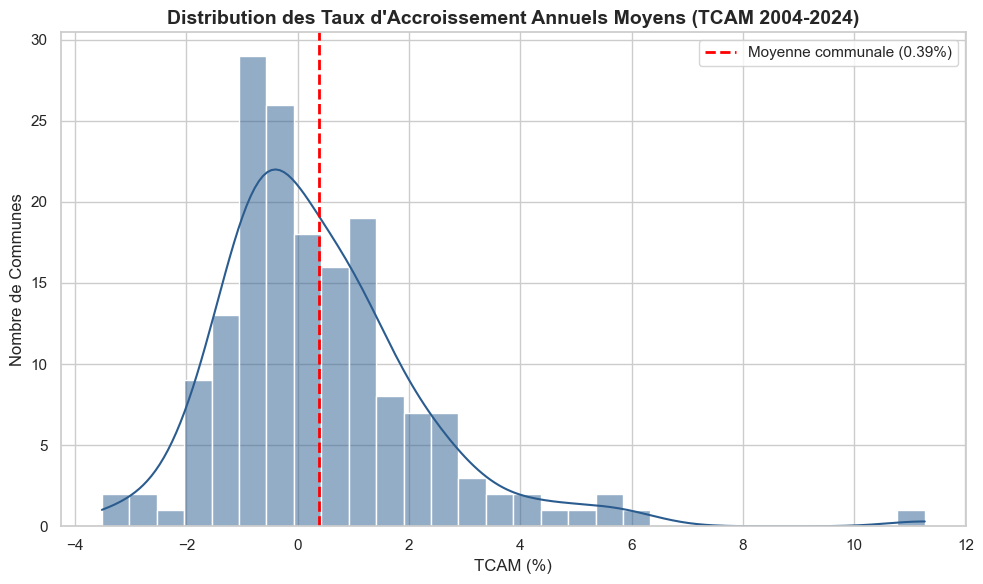

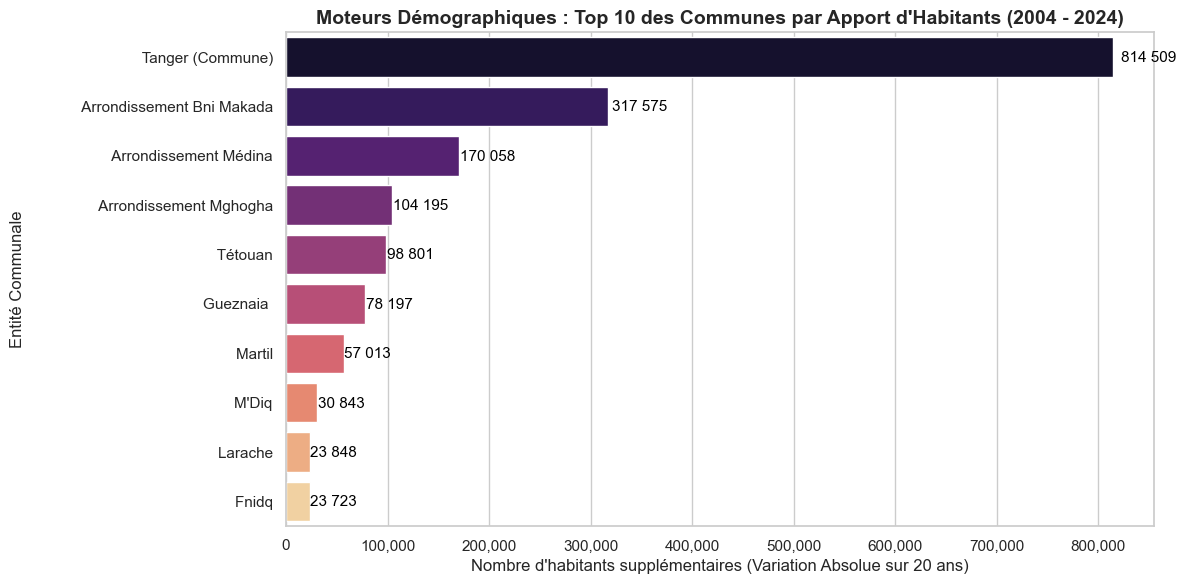

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==============================================================================
# SCRIPT D'ANALYSE EXPLORATOIRE (EDA) - DYNAMIQUE DE CROISSANCE (FILTRÉ)
# ==============================================================================

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14, 'axes.titleweight': 'bold'})

# 1. Chargement des données
df = pd.read_csv("population_preparee_finale.csv", sep=";", decimal=",", encoding="utf-8-sig")

# ==============================================================================
# 🚨 FILTRAGE DU NIVEAU HIÉRARCHIQUE (CORRIGÉ ET BLINDÉ)
# ==============================================================================
print("\n[FILTRAGE] Suppression des niveaux National, Régional et Provincial...")

taille_avant = len(df)

# 1. On supprime le National et la Région b l'mot clé (contains) bach ntsidou l'espaces mkhfyin
mots_macro = 'National|Tanger-Tétouan|Tanger-Tetouan'
df = df[~df['zone_geographique'].str.contains(mots_macro, case=False, na=False, regex=True)]

# 2. On supprime les Provinces et Préfectures (nzedo l'accent l'Préf)
mots_prov = r'\(Prov\)|\(Pref\)|\(Préf\)'
df = df[~df['zone_geographique'].str.contains(mots_prov, case=False, na=False, regex=True)]

taille_apres = len(df)
lignes_supprimees = taille_avant - taille_apres

print(f"  ✅ Filtrage réussi : {lignes_supprimees} lignes macro-géographiques supprimées.")
print(f"  → Il reste exactement {taille_apres} vraies communes dans le dataset.\n")

# ==============================================================================
# FIGURE 3 : Distribution du Taux d'Accroissement (TCAM)
# ==============================================================================
plt.figure(figsize=(10, 6))
ax1 = sns.histplot(data=df, x='tcam_2004_2024_pct', bins=30, kde=True, color='#2b5c8f', edgecolor='white')

moyenne_tcam = df['tcam_2004_2024_pct'].mean()
plt.axvline(moyenne_tcam, color='red', linestyle='--', linewidth=2, label=f'Moyenne communale ({moyenne_tcam:.2f}%)')

plt.title("Distribution des Taux d'Accroissement Annuels Moyens (TCAM 2004-2024)")
plt.xlabel("TCAM (%)")
plt.ylabel("Nombre de Communes")
plt.legend()
plt.tight_layout()
plt.savefig('fig_03_distribution_tcam.png', dpi=300)
plt.show()

# ==============================================================================
# FIGURE 4 : Les Moteurs de Croissance (Top 10 Variation Absolue 2004 - 2024)
# ==============================================================================
# 1. Calcul de la nouvelle variation (2024 - 2004)
df['variation_abs_2004_2024'] = df['pop_2024'].astype(float) - df['pop_2004'].astype(float)

# 2. Trier pour trouver le Top 10 sur ces 20 ans
df_top_variation_20 = df.sort_values(by='variation_abs_2004_2024', ascending=False).head(10)

plt.figure(figsize=(12, 6))
ax2 = sns.barplot(data=df_top_variation_20, x='variation_abs_2004_2024', y='zone_geographique', palette='magma')

# 3. Mise à jour des titres et labels
plt.title("Moteurs Démographiques : Top 10 des Communes par Apport d'Habitants (2004 - 2024)")
plt.xlabel("Nombre d'habitants supplémentaires (Variation Absolue sur 20 ans)")
plt.ylabel("Entité Communale")

# Formatage des nombres sur l'axe X (espaces pour les milliers)
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

# Ajout des valeurs sur les barres
for p in ax2.patches:
    width = p.get_width()
    plt.text(width + (width * 0.01), p.get_y() + p.get_height()/2. + 0.1, 
             '{:,.0f}'.format(width).replace(',', ' '), ha="left", color='black', fontsize=11)

plt.tight_layout()
plt.savefig('fig_04_top_variation_absolue_2004_2024.png', dpi=300)
plt.show()


[VALIDATION] Vérification de la cohérence de la dynamique régionale...


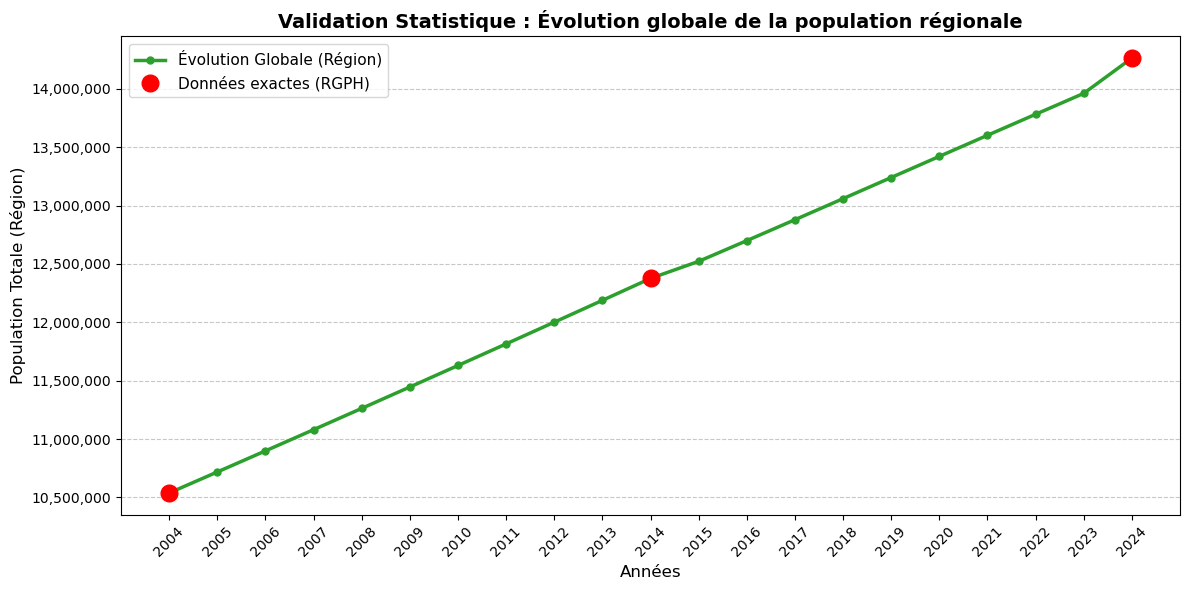

✅ Validation réussie : Le graphe contient maintenant la courbe verte !


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# 0. Chargement des données
df = pd.read_csv("population_preparee_finale.csv", sep=";", decimal=",", encoding="utf-8-sig")

print("\n[VALIDATION] Vérification de la cohérence de la dynamique régionale...")

# 1. Extraction dynamique des années (colonnes nommées pop_2004, pop_2005, ...)
colonnes_annees = [col for col in df.columns if col.startswith('pop_') and col[4:].isdigit()]
colonnes_annees.sort(key=lambda x: int(x[4:]))

# 2. Forcer le format numérique
for col in colonnes_annees:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(r'\s+', '', regex=True).str.replace(',', '.'),
        errors='coerce'
    )

# 3. Calcul de l'évolution régionale (sans la ligne National)
df_regions = df[df['zone_geographique'].str.strip() != 'National']
evolution = df_regions[colonnes_annees].sum()

# 4. Préparation des données pour le graphe
x_labels = [col[4:] for col in colonnes_annees]  # 2004, 2005, ...
y_values = evolution.values

# 5. Identifier les années RGPH
rgph_years = ['2004', '2014', '2024']
rgph_indices = [x_labels.index(y) for y in rgph_years if y in x_labels]
x_rgph = [x_labels[i] for i in rgph_indices]
y_rgph = [y_values[i] for i in rgph_indices]

# 6. Visualisation
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(x_labels, y_values, marker='o', markersize=5, linestyle='-',
        color='#2ca02c', linewidth=2.5, label='Évolution Globale (Région)')

ax.plot(x_rgph, y_rgph, 'ro', markersize=12, zorder=5, label='Données exactes (RGPH)')

ax.set_title("Validation Statistique : Évolution globale de la population régionale",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Années", fontsize=12)
ax.set_ylabel("Population Totale (Région)", fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(fontsize=11)
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.savefig('fig_05_validation_regionale.png', dpi=300)
plt.show()

print("✅ Validation réussie : Le graphe contient maintenant la courbe verte !")


In [9]:
!pip install prophet pmdarima

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.1 MB 6.9 MB/s eta 0:00:02
   -------- ------------------------------- 2.6/12.1 MB 7.5 MB/s eta 0:00:02
   ------------ --------------------------- 3.9/12.1 MB 6.9 MB/s eta 0:00:02
   ----------------- ---------------------- 5.2/12.1 MB 6.8 MB/s eta 0:00:02
   ---------------------- ----------------- 6.8/12.1 MB 6.7 MB/s eta 0:00:01
   -------------------------- ------------- 8.1/12.1 MB 6.7 MB/s eta 0:00:01
   ------------------------------- -------- 9.4/12.1 MB 6.7 MB/s eta 0:00:01
   ------------------------------------ --- 11.0/12.1 MB 6.8 MB/s eta 0:00:01
   ---------------------------------------  12.1/12.1 MB 6.8 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 6.2 MB/s  0:00:01
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.5 MB 4.1 MB/s eta 0:00:01
   ------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\LENOVO\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [5]:
# ============================================================
# BACKTESTING D'IMPUTATION DEMOGRAPHIQUE
# Benchmark : Arithmétique vs Géométrique/TCAM vs Spline
# Données : populations réelles 2004, 2014, 2024
# Objectif : choisir la meilleure méthode pour reconstituer
#            les années inter-censitaires 2005-2013 et 2015-2023
# ============================================================

import numpy as np
import pandas as pd
from scipy.interpolate import interp1d, UnivariateSpline


# ============================================================
# 1. PARAMÈTRES GÉNÉRAUX
# ============================================================

INPUT_FILE = "indicateur_population.csv"

COL_ZONE = "Zone géographique"
COL_2004 = "2004"
COL_2014 = "2014"
COL_2024 = "2024"

EPSILON = 1e-9  # sécurité numérique contre les divisions par zéro


# ============================================================
# 2. FONCTIONS UTILITAIRES
# ============================================================

def clean_population_column(series: pd.Series) -> pd.Series:
    """
    Nettoie une colonne de population :
    - remplace les tirets ou valeurs invalides par NaN
    - convertit en float64
    - garantit une précision numérique stable
    """
    return (
        series
        .replace(["-", "", " ", "NA", "N/A", "nan", "NaN"], np.nan)
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(np.float64)
    )


def safe_mape(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    """
    Calcule le MAPE de manière robuste.
    Pour éviter les divisions par zéro, on utilise EPSILON.
    """
    denominator = np.maximum(np.abs(y_true), EPSILON)
    return np.abs((y_true - y_pred) / denominator) * 100


def safe_mae(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    """
    Calcule l'erreur absolue moyenne en volume.
    """
    return np.abs(y_true - y_pred)


def predict_spline_2024(pop_2004: float, pop_2014: float) -> float:
    """
    Modèle 3 : interpolation/extrapolation non-linéaire.

   
    """

    years = np.array([2004, 2014], dtype=np.float64)
    values = np.array([pop_2004, pop_2014], dtype=np.float64)

    valid_mask = np.isfinite(values)
    years_valid = years[valid_mask]
    values_valid = values[valid_mask]

    n_points = len(values_valid)

    if n_points < 2:
        return np.nan

    # Avec 2 points, degré maximal possible = 1
    k = min(3, n_points - 1)

    try:
        if k == 1:
            model = interp1d(
                years_valid,
                values_valid,
                kind="linear",
                fill_value="extrapolate",
                bounds_error=False
            )
            return np.float64(model(2024))

        else:
            model = UnivariateSpline(
                years_valid,
                values_valid,
                k=k,
                s=0
            )
            return np.float64(model(2024))

    except Exception:
        return np.nan


# ============================================================
# 3. CHARGEMENT ET PRÉPARATION DES DONNÉES
# ============================================================

df = pd.read_csv(INPUT_FILE)

# Vérification des colonnes minimales
required_columns = [COL_ZONE, COL_2004, COL_2014, COL_2024]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Colonnes manquantes dans le fichier : {missing_columns}")

# Nettoyage et conversion en float64
for col in [COL_2004, COL_2014, COL_2024]:
    df[col] = clean_population_column(df[col])

# On conserve uniquement les lignes exploitables
df = df.dropna(subset=[COL_2004, COL_2014, COL_2024]).copy()

# Sécurité : suppression des populations négatives
df = df[
    (df[COL_2004] >= 0) &
    (df[COL_2014] >= 0) &
    (df[COL_2024] >= 0)
].copy()

# Passage explicite en float64
df[COL_2004] = df[COL_2004].astype(np.float64)
df[COL_2014] = df[COL_2014].astype(np.float64)
df[COL_2024] = df[COL_2024].astype(np.float64)


# ============================================================
# 4. ÉTAPE 1 : DATA MASKING
# ============================================================

# La population réelle de 2024 est isolée comme Ground Truth
df["Pop_2024_Reelle"] = df[COL_2024].astype(np.float64)

# Les modèles n'ont accès qu'à 2004 et 2014
df["Pop_2004"] = df[COL_2004].astype(np.float64)
df["Pop_2014"] = df[COL_2014].astype(np.float64)


# ============================================================
# 5. ÉTAPE 2 : MODÈLE 1 - CROISSANCE ARITHMÉTIQUE
# ============================================================

df["r_arith"] = (df["Pop_2014"] - df["Pop_2004"]) / 10.0

df["Pred_2024_Arith"] = df["Pop_2014"] + (df["r_arith"] * 10.0)


# ============================================================
# 6. ÉTAPE 3 : MODÈLE 2 - CROISSANCE GÉOMÉTRIQUE / TCAM
# ============================================================

# Cas standard : Pop_2004 > 0
valid_geom = df["Pop_2004"] > EPSILON

df["TCAM"] = np.nan

df.loc[valid_geom, "TCAM"] = (
    (df.loc[valid_geom, "Pop_2014"] / df.loc[valid_geom, "Pop_2004"]) ** (1.0 / 10.0)
) - 1.0

df["Pred_2024_Geom"] = np.nan

df.loc[valid_geom, "Pred_2024_Geom"] = (
    df.loc[valid_geom, "Pop_2014"] *
    ((1.0 + df.loc[valid_geom, "TCAM"]) ** 10.0)
)

# Pour les cas où Pop_2004 vaut 0 ou est trop faible,
# on utilise un fallback arithmétique pour éviter une explosion numérique.
df.loc[~valid_geom, "Pred_2024_Geom"] = df.loc[~valid_geom, "Pred_2024_Arith"]


# ============================================================
# 7. ÉTAPE 4 : MODÈLE 3 - SPLINES / EXTRAPOLATION
# ============================================================

df["Pred_2024_Spline"] = df.apply(
    lambda row: predict_spline_2024(
        row["Pop_2004"],
        row["Pop_2014"]
    ),
    axis=1
)

# Fallback si la spline échoue
df["Pred_2024_Spline"] = df["Pred_2024_Spline"].fillna(df["Pred_2024_Arith"])


# ============================================================
# 8. ÉTAPE 5 : ÉVALUATION ET BENCHMARKING
# ============================================================

models = {
    "Arithmétique": "Pred_2024_Arith",
    "Géométrique_TCAM": "Pred_2024_Geom",
    "Spline": "Pred_2024_Spline"
}

for model_name, pred_col in models.items():
    df[f"MAPE_{model_name}"] = safe_mape(
        df["Pop_2024_Reelle"].values,
        df[pred_col].values
    )

    df[f"MAE_{model_name}"] = safe_mae(
        df["Pop_2024_Reelle"].values,
        df[pred_col].values
    )


# ============================================================
# 9. SYNTHÈSE GLOBALE
# ============================================================

summary_rows = []

for model_name in models.keys():
    summary_rows.append({
        "Modèle": model_name,
        "MAPE moyen (%)": df[f"MAPE_{model_name}"].mean(),
        "MAPE médian (%)": df[f"MAPE_{model_name}"].median(),
        "MAE moyenne": df[f"MAE_{model_name}"].mean(),
        "MAE totale": df[f"MAE_{model_name}"].sum()
    })

summary = pd.DataFrame(summary_rows)

summary = summary.sort_values(
    by="MAPE moyen (%)",
    ascending=True
).reset_index(drop=True)

print("\n==============================")
print("BENCHMARK GLOBAL DES MÉTHODES")
print("==============================\n")
print(summary)


# ============================================================
# 10. DÉCISION AUTOMATIQUE
# ============================================================

winning_model = summary.loc[0, "Modèle"]

print("\n==============================")
print("DÉCISION AUTOMATIQUE")
print("==============================\n")

print(
    f"La méthode [{winning_model}] est la plus performante. "
    "C'est elle qui sera retenue pour lisser et reconstituer toute la base de données inter-censitaire."
)


# ============================================================
# 11. EXPORT DES RÉSULTATS DÉTAILLÉS
# ============================================================

output_columns = [
    COL_ZONE,
    "Pop_2004",
    "Pop_2014",
    "Pop_2024_Reelle",
    "Pred_2024_Arith",
    "Pred_2024_Geom",
    "Pred_2024_Spline",
    "MAPE_Arithmétique",
    "MAPE_Géométrique_TCAM",
    "MAPE_Spline",
    "MAE_Arithmétique",
    "MAE_Géométrique_TCAM",
    "MAE_Spline"
]

df_results = df[output_columns].copy()

df_results.to_csv(
    "benchmark_imputation_population_2024.csv",
    index=False,
    encoding="utf-8-sig"
)

summary.to_csv(
    "synthese_benchmark_imputation.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nFichiers exportés :")
print("- benchmark_imputation_population_2024.csv")
print("- synthese_benchmark_imputation.csv")


BENCHMARK GLOBAL DES MÉTHODES

             Modèle  MAPE moyen (%)  MAPE médian (%)   MAE moyenne  \
0      Arithmétique       13.273137         9.273400  10429.514124   
1            Spline       13.273137         9.273400  10429.514124   
2  Géométrique_TCAM       14.168907         9.355958  13398.561733   

     MAE totale  
0  1.846024e+06  
1  1.846024e+06  
2  2.371545e+06  

DÉCISION AUTOMATIQUE

La méthode [Arithmétique] est la plus performante. C'est elle qui sera retenue pour lisser et reconstituer toute la base de données inter-censitaire.

Fichiers exportés :
- benchmark_imputation_population_2024.csv
- synthese_benchmark_imputation.csv


In [5]:
# ============================================================
# PIPELINE DE RECONSTITUTION HYBRIDE DES POPULATIONS COMMUNALES
# Projet : Projections démographiques HCP
# Période finale : 2004-2024
#
# Phase 1 : 2005-2013 par interpolation géométrique TCAM
# Phase 2 : 2015-2023 par calibrage progressif des estimations HCP
# Phase 3 : export Wide + Long pour Machine Learning
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. PARAMÈTRES GÉNÉRAUX
# ============================================================

INPUT_FILE = "indicateur_population.csv"

OUTPUT_WIDE = "population_reconstituee_hybride_wide.csv"
OUTPUT_LONG = "population_reconstituee_hybride_long.csv"

COL_ZONE = "Zone géographique"

YEAR_2004 = "2004"
YEAR_2014 = "2014"
YEAR_2024 = "2024"

YEARS_INTERPOLATION = list(range(2005, 2014))  # 2005-2013
YEARS_HCP = list(range(2015, 2024))            # 2015-2023
YEARS_FINAL = list(range(2004, 2025))          # 2004-2024

EPSILON = 1e-9


# ============================================================
# 2. FONCTIONS UTILITAIRES
# ============================================================

def clean_numeric_column(series: pd.Series) -> pd.Series:
    """
    Nettoie une colonne numérique et la convertit en float64.

    Objectif :
    - garder la précision maximale pendant tout le pipeline ;
    - éviter les erreurs liées aux virgules, tirets ou chaînes vides.
    """
    return (
        series
        .replace(["-", "", " ", "NA", "N/A", "nan", "NaN", None], np.nan)
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(np.float64)
    )


def safe_tcam(pop_start: pd.Series, pop_end: pd.Series, n_years: int = 10) -> pd.Series:
    """
    Calcule le TCAM de manière sécurisée.

    Formule :
        TCAM = (Pop_end / Pop_start)^(1/n_years) - 1

    Gestion des cas problématiques :
    - si Pop_start <= 0, le TCAM géométrique est impossible ;
    - on retourne NaN, puis on utilisera un fallback linéaire.
    """
    pop_start = pop_start.astype(np.float64)
    pop_end = pop_end.astype(np.float64)

    valid = (pop_start > EPSILON) & (pop_end >= 0)

    tcam = pd.Series(np.nan, index=pop_start.index, dtype=np.float64)

    tcam.loc[valid] = (
        (pop_end.loc[valid] / pop_start.loc[valid]) ** (1.0 / n_years)
    ) - 1.0

    return tcam


# ============================================================
# 3. CHARGEMENT ET CONTRÔLE DES DONNÉES
# ============================================================

df_raw = pd.read_csv(INPUT_FILE)

required_columns = (
    [COL_ZONE, YEAR_2004, YEAR_2014, YEAR_2024]
    + [str(y) for y in YEARS_HCP]
)

missing_columns = [col for col in required_columns if col not in df_raw.columns]

if missing_columns:
    raise ValueError(
        f"Colonnes manquantes dans le fichier source : {missing_columns}"
    )

df = df_raw.copy()

numeric_cols = [str(y) for y in [2004, 2014] + YEARS_HCP + [2024]]

for col in numeric_cols:
    df[col] = clean_numeric_column(df[col])

# ============================================================
# FILTRAGE DES CENTRES SANS HISTORIQUE
# ============================================================

# Objectif :
# Supprimer les centres/communes qui existent uniquement en 2024
# et qui n'ont pas de données historiques suffisantes avant 2024.

initial_count = len(df)

df = df[
    df[YEAR_2004].notna()
    & df[YEAR_2014].notna()
    & df[YEAR_2024].notna()
].copy()

removed_count = initial_count - len(df)

print("\n==============================================")
print("FILTRAGE DES CENTRES SANS HISTORIQUE")
print("==============================================")
print(f"Nombre d'entités initiales  : {initial_count}")
print(f"Nombre d'entités supprimées : {removed_count}")
print(f"Nombre d'entités conservées : {len(df)}")

# Suppression des lignes sans identifiant géographique
df = df.dropna(subset=[COL_ZONE]).copy()

# Passage explicite en float64
for col in numeric_cols:
    df[col] = df[col].astype(np.float64)


# ============================================================
# 4. PHASE 1 : INTERPOLATION GÉOMÉTRIQUE 2005-2013
# ============================================================

df["TCAM_2004_2014"] = safe_tcam(
    pop_start=df[YEAR_2004],
    pop_end=df[YEAR_2014],
    n_years=10
)

# Fallback linéaire si TCAM impossible
# Exemple : Pop_2004 = 0
df["Increment_Lineaire_2004_2014"] = (
    df[YEAR_2014] - df[YEAR_2004]
) / 10.0

for year in YEARS_INTERPOLATION:
    year_str = str(year)
    exponent = year - 2004

    # Cas géométrique valide
    geom_values = (
        df[YEAR_2004]
        * ((1.0 + df["TCAM_2004_2014"]) ** exponent)
    )

    # Fallback linéaire pour populations nulles ou TCAM non calculable
    linear_values = (
        df[YEAR_2004]
        + df["Increment_Lineaire_2004_2014"] * exponent
    )

    df[year_str] = np.where(
        df["TCAM_2004_2014"].notna(),
        geom_values,
        linear_values
    ).astype(np.float64)


# ============================================================
# 5. PHASE 2 : CALIBRAGE RÉTROSPECTIF 2015-2023
# ============================================================

# Erreur finale observée en 2024 :
# Erreur = RGPH réel 2024 - estimation/projection HCP 2024
#
# Attention :
# Dans ce fichier, la colonne 2024 est considérée comme RGPH réel.
# Si tu as une colonne séparée HCP_2024, remplace df[YEAR_2024]
# dans Pop_HCP_2024 par cette colonne.

if "HCP_2024" in df.columns:
    df["Pop_HCP_2024"] = clean_numeric_column(df["HCP_2024"])
else:
    # Cas de ton fichier actuel :
    # comme on n'a pas de colonne HCP_2024 distincte, on suppose que
    # la trajectoire HCP 2015-2023 doit être calibrée vers le RGPH 2024.
    #
    # Pour calculer une erreur HCP 2024, il faut idéalement une vraie
    # estimation HCP 2024. À défaut, on extrapole temporairement HCP_2024
    # à partir de la tendance HCP 2022-2023.
    df["Pop_HCP_2024"] = df["2023"] + (df["2023"] - df["2022"])

df["Erreur_HCP_2024"] = (
    df[YEAR_2024] - df["Pop_HCP_2024"]
).astype(np.float64)

for year in YEARS_HCP:
    year_str = str(year)

    poids = (year - 2014) / 10.0

    df[year_str] = (
        df[year_str]
        + df["Erreur_HCP_2024"] * poids
    ).astype(np.float64)


# Forcer les années d'ancrage réelles
df["2004"] = df[YEAR_2004].astype(np.float64)
df["2014"] = df[YEAR_2014].astype(np.float64)
df["2024"] = df[YEAR_2024].astype(np.float64)


# ============================================================
# 6. PHASE 3 : FORMATAGE FINAL WIDE
# ============================================================

final_year_cols = [str(y) for y in YEARS_FINAL]

df_wide = df[[COL_ZONE] + final_year_cols].copy()

# Conservation float64 jusqu'ici
for col in final_year_cols:
    df_wide[col] = df_wide[col].astype(np.float64)


# ============================================================
# 7. VERSION ARRONDIE FINALE
# ============================================================

df_wide_rounded = df_wide.copy()

for col in final_year_cols:
    df_wide_rounded[col] = df_wide_rounded[col].round(0).astype("Int64")


# ============================================================
# 8. FORMAT LONG / TIDY DATA
# ============================================================

df_long = df_wide_rounded.melt(
    id_vars=[COL_ZONE],
    value_vars=final_year_cols,
    var_name="Année",
    value_name="Population"
)

df_long["Année"] = df_long["Année"].astype(int)
df_long["Population"] = df_long["Population"].astype("Int64")

df_long = df_long.sort_values(
    by=[COL_ZONE, "Année"]
).reset_index(drop=True)


# ============================================================
# 9. EXPORT DES RÉSULTATS
# ============================================================

df_wide_rounded.to_csv(
    OUTPUT_WIDE,
    index=False,
    encoding="utf-8-sig"
)

df_long.to_csv(
    OUTPUT_LONG,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 10. RAPPORT DE CONTRÔLE
# ============================================================

print("\n==============================================")
print("PIPELINE DE RECONSTITUTION HYBRIDE TERMINÉ")
print("==============================================\n")

print(f"Nombre d'entités traitées : {len(df_wide_rounded)}")
print(f"Période reconstruite      : {YEARS_FINAL[0]}-{YEARS_FINAL[-1]}")

print("\nFichiers générés :")
print(f"- {OUTPUT_WIDE}")
print(f"- {OUTPUT_LONG}")

print("\nAperçu format Wide :")
print(df_wide_rounded.head())

print("\nAperçu format Long :")
print(df_long.head(15))

print("\nContrôle des années disponibles :")
print(df_long.groupby("Année")["Population"].count())


FILTRAGE DES CENTRES SANS HISTORIQUE
Nombre d'entités initiales  : 180
Nombre d'entités supprimées : 4
Nombre d'entités conservées : 176

PIPELINE DE RECONSTITUTION HYBRIDE TERMINÉ

Nombre d'entités traitées : 176
Période reconstruite      : 2004-2024

Fichiers générés :
- population_reconstituee_hybride_wide.csv
- population_reconstituee_hybride_long.csv

Aperçu format Wide :
               Zone géographique      2004      2005      2006      2007  \
0                       National  29891708  30265599  30644166  31027469   
1      Tanger-Tétouan-Al Hoceima   3068833   3114447   3160740   3207720   
2              Al Hoceima (Prov)    395644    396043    396443    396843   
3                     Al Hoceima     55357     55491     55626     55761   
4                   Bni Bouayach     15497     15754     16016     16282   

       2008      2009      2010      2011      2012  ...      2015      2016  \
0  31415566  31808517  32206384  32609227  33017109  ...  34070248  34377291   
1 

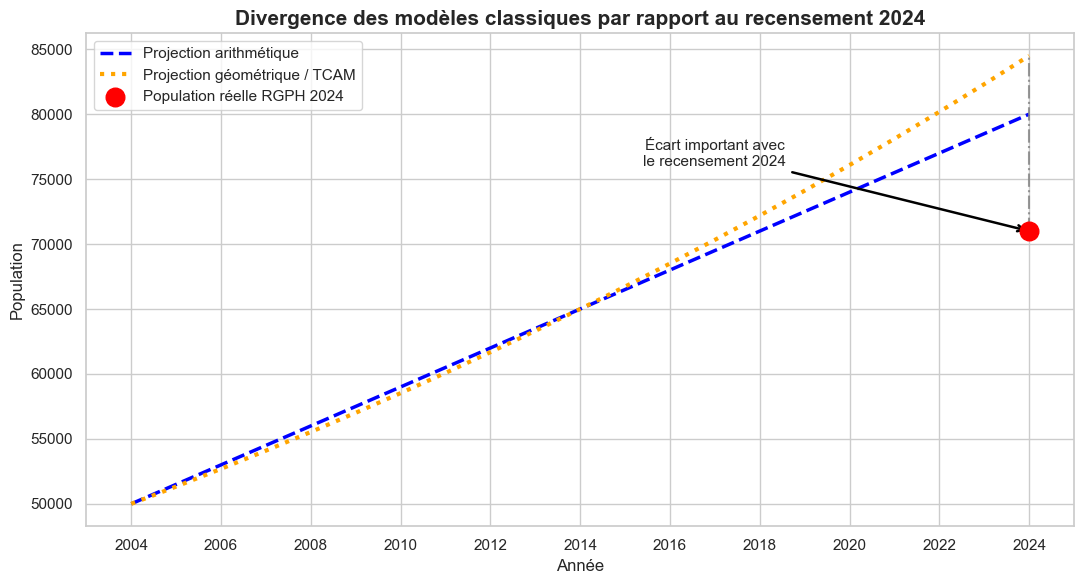

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Données de base
pop_2004 = 50000
pop_2014 = 65000
pop_2024_reelle = 71000

years = np.arange(2004, 2025)

# Croissance arithmétique
r_arith = (pop_2014 - pop_2004) / 10
pop_arith = pop_2004 + r_arith * (years - 2004)

# Croissance géométrique / TCAM
tcam = (pop_2014 / pop_2004) ** (1 / 10) - 1
pop_geom = pop_2004 * (1 + tcam) ** (years - 2004)

# DataFrame pour visualisation
df_plot = pd.DataFrame({
    "Année": years,
    "Arithmétique": pop_arith,
    "Géométrique": pop_geom
})

# Style académique
sns.set_theme(style="whitegrid")

plt.figure(figsize=(11, 6))

plt.plot(
    df_plot["Année"],
    df_plot["Arithmétique"],
    color="blue",
    linestyle="--",
    linewidth=2.5,
    label="Projection arithmétique"
)

plt.plot(
    df_plot["Année"],
    df_plot["Géométrique"],
    color="orange",
    linestyle=":",
    linewidth=3,
    label="Projection géométrique / TCAM"
)

plt.scatter(
    2024,
    pop_2024_reelle,
    color="red",
    s=180,
    zorder=5,
    label="Population réelle RGPH 2024"
)

pred_arith_2024 = pop_arith[-1]
pred_geom_2024 = pop_geom[-1]

plt.annotate(
    "Écart important avec\nle recensement 2024",
    xy=(2024, pop_2024_reelle),
    xytext=(2017, 76000),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.8,
        color="black"
    ),
    fontsize=11,
    ha="center"
)

plt.vlines(
    x=2024,
    ymin=pop_2024_reelle,
    ymax=pred_geom_2024,
    color="gray",
    linestyle="-.",
    linewidth=1.5,
    alpha=0.8
)

plt.title(
    "Divergence des modèles classiques par rapport au recensement 2024",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Année", fontsize=12)
plt.ylabel("Population", fontsize=12)

plt.xticks(np.arange(2004, 2025, 2))
plt.legend(fontsize=11)
plt.tight_layout()

plt.savefig("divergence_modeles_classiques_2024.png", dpi=300, bbox_inches="tight")
plt.show()

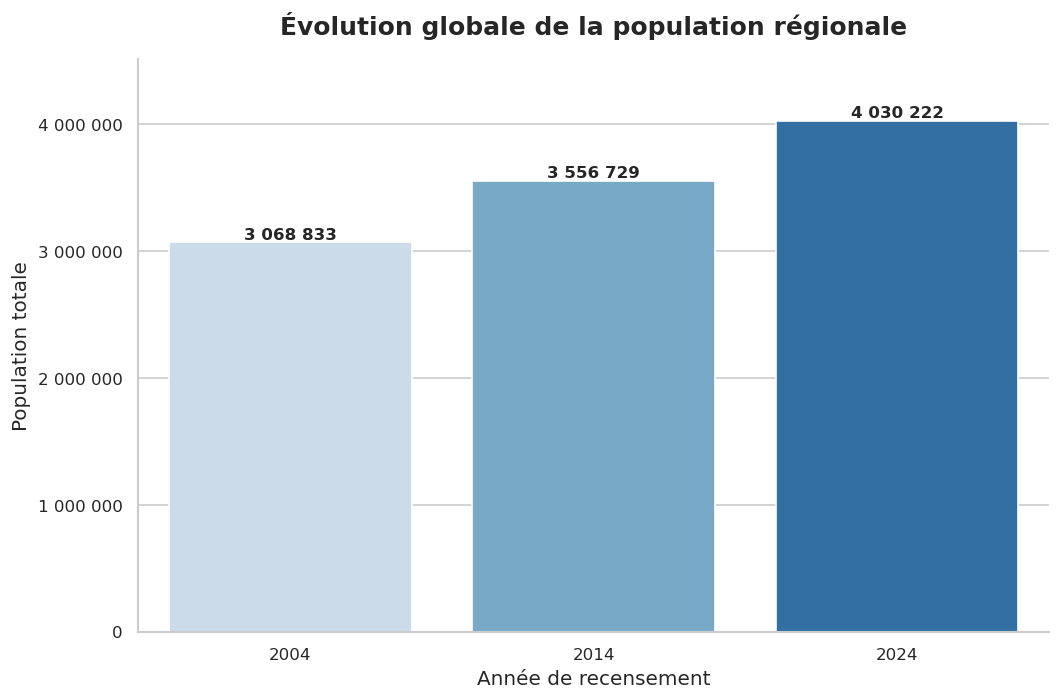

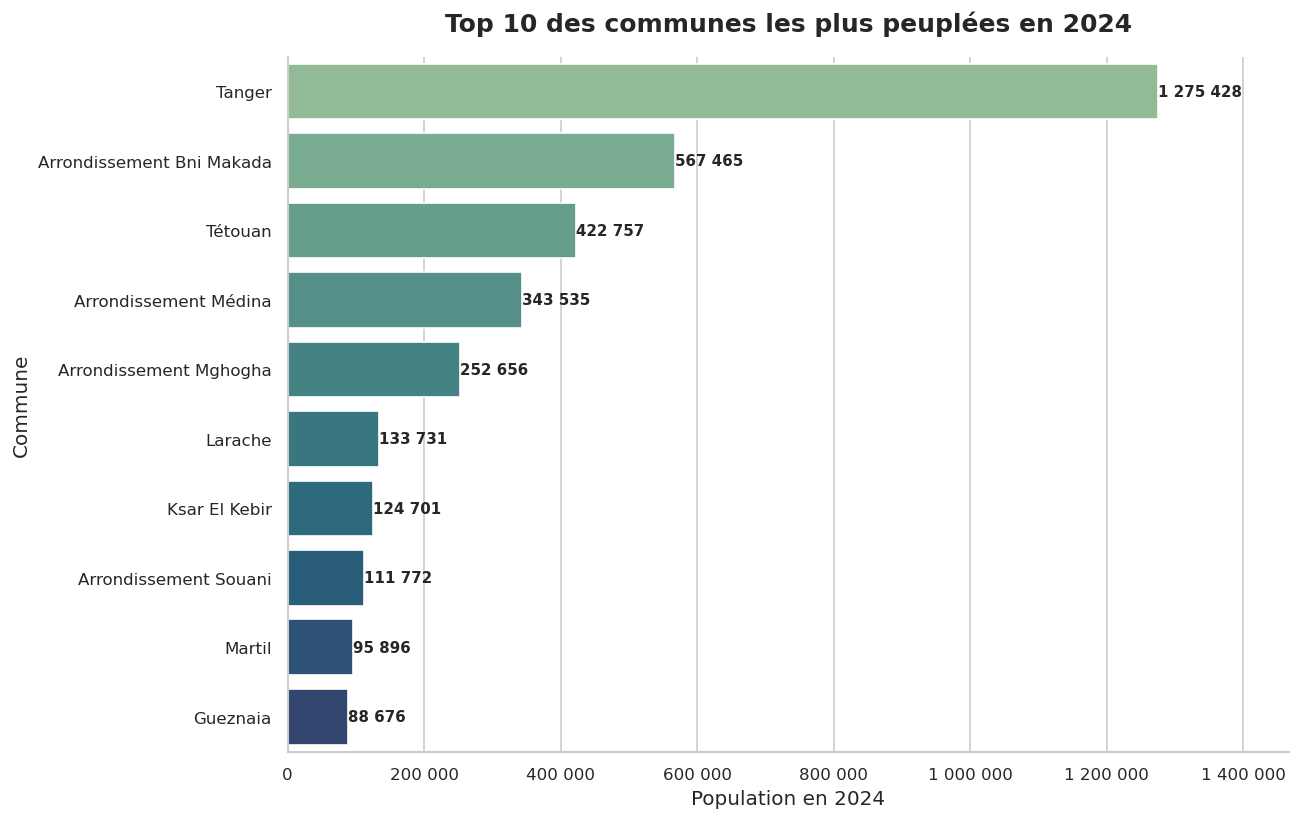

Graphes générés avec succès :
- eda_1_evolution_globale_population_regionale.png
- eda_2_top10_communes_2024.png

Valeurs utilisées pour le graphe régional :
  Année  Population
0  2004   3068833.0
1  2014   3556729.0
2  2024   4030222.0

Top 10 des communes en 2024 :
                       Commune     2024
131                     Tanger  1275428
133  Arrondissement Bni Makada   567465
151                    Tétouan   422757
136      Arrondissement Médina   343535
134     Arrondissement Mghogha   252656
87                     Larache   133731
86               Ksar El Kebir   124701
135      Arrondissement Souani   111772
176                     Martil    95896
137                   Gueznaia    88676


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. Chargement des données
# ============================================================

INPUT_FILE = "indicateur_population.csv"
COL_ZONE = "Zone géographique"
YEARS = ["2004", "2014", "2024"]

df = pd.read_csv(INPUT_FILE)

# ============================================================
# 2. Nettoyage
# ============================================================

for col in YEARS:
    df[col] = (
        df[col]
        .replace(["-", "", " ", "NA", "N/A", "nan", "NaN"], np.nan)
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace(" ", "", regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[COL_ZONE] = df[COL_ZONE].astype(str).str.strip()

# ============================================================
# 3. Style graphique
# ============================================================

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# ============================================================
# 4. Graphe 1 : Évolution globale de la population régionale
#    (à partir de la ligne régionale)
# ============================================================

mask_region = df[COL_ZONE].str.lower().str.contains(
    r"tanger[\s\-–—]*t[ée]touan[\s\-–—]*al[\s\-–—]*hoceima",
    regex=True,
    na=False
)

df_region = df.loc[mask_region].copy()

if df_region.empty:
    raise ValueError("La ligne régionale 'Tanger-Tétouan-Al Hoceima' est introuvable dans le fichier.")

region_row = df_region.iloc[0]

evolution_region = pd.DataFrame({
    "Année": YEARS,
    "Population": [region_row["2004"], region_row["2014"], region_row["2024"]]
})

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=evolution_region,
    x="Année",
    y="Population",
    hue="Année",
    palette="Blues",
    legend=False
)
for i, value in enumerate(evolution_region["Population"]):
    ax.text(
        i,
        value,
        f"{value:,.0f}".replace(",", " "),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title("Évolution globale de la population régionale", fontweight="bold", pad=15)
ax.set_xlabel("Année de recensement")
ax.set_ylabel("Population totale")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", " "))
)

ax.set_ylim(0, evolution_region["Population"].max() * 1.12)

sns.despine()
plt.tight_layout()
plt.savefig("eda_1_evolution_globale_population_regionale.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 5. Graphe 2 : Top 10 des communes les plus peuplées en 2024
#    (uniquement selon la disponibilité de 2024)
# ============================================================

pattern_exclusion = (
    r"national|"
    r"tanger[\s\-–—]*t[ée]touan[\s\-–—]*al[\s\-–—]*hoceima|"
    r"prov|"
    r"pr[ée]f"
)

df_top = df[
    ~df[COL_ZONE].str.lower().str.contains(pattern_exclusion, regex=True, na=False)
].copy()

# garder uniquement les lignes ayant une valeur en 2024
df_top = df_top.dropna(subset=["2024"]).copy()

# nettoyage léger des noms
df_top["Commune"] = (
    df_top[COL_ZONE]
    .str.replace(r"\(Commune\)", "", regex=True)
    .str.replace(r"\(Mun\.\)", "", regex=True)
    .str.strip()
)

top10_2024 = (
    df_top.sort_values("2024", ascending=False)
    .head(10)
    .copy()
)

plt.figure(figsize=(11, 7))

ax = sns.barplot(
    data=top10_2024,
    x="2024",
    y="Commune",
    hue="Commune",
    order=top10_2024["Commune"],
    palette="crest",
    legend=False
)

for i, value in enumerate(top10_2024["2024"]):
    ax.text(
        value,
        i,
        f"{value:,.0f}".replace(",", " "),
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold"
    )

ax.set_title("Top 10 des communes les plus peuplées en 2024", fontweight="bold", pad=15)
ax.set_xlabel("Population en 2024")
ax.set_ylabel("Commune")

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", " "))
)

ax.set_xlim(0, top10_2024["2024"].max() * 1.15)

sns.despine()
plt.tight_layout()
plt.savefig("eda_2_top10_communes_2024.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 6. Exports de contrôle
# ============================================================

evolution_region.to_csv(
    "controle_evolution_regionale.csv",
    index=False,
    encoding="utf-8-sig"
)

top10_2024[["Commune", "2024"]].to_csv(
    "controle_top10_communes_2024.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Graphes générés avec succès :")
print("- eda_1_evolution_globale_population_regionale.png")
print("- eda_2_top10_communes_2024.png")

print("\nValeurs utilisées pour le graphe régional :")
print(evolution_region)

print("\nTop 10 des communes en 2024 :")
print(top10_2024[["Commune", "2024"]])

In [4]:
"""
merge_hcp2024.py
────────────────
Lit indicateur_population.csv et 2024.csv.
Ajoute une colonne HCP_2024_estime à indicateur_population.csv
en fusionnant sur Zone géographique après normalisation stricte
(minuscules, strip, suppression des accents, espaces multiples réduits).
Aucun fuzzy-matching : correspondance exacte normalisée uniquement.
Sortie : indicateur_population_avec_hcp2024.csv
"""

import unicodedata
import re
import pandas as pd


# ── Helpers ────────────────────────────────────────────────────────────────

def normalize(text: str) -> str:
    """Minuscules · strip · retrait des accents · espaces multiples → un seul."""
    if not isinstance(text, str):
        return ""
    # Minuscules + strip
    text = text.strip().lower()
    # Retrait des accents (décomposition NFD puis suppression des marques)
    text = unicodedata.normalize("NFD", text)
    text = "".join(c for c in text if unicodedata.category(c) != "Mn")
    # Espaces multiples → un seul espace
    text = re.sub(r"\s+", " ", text)
    return text


# ── Chargement ─────────────────────────────────────────────────────────────

df_indic = pd.read_csv("indicateur_population.csv")
df_2024  = pd.read_csv("population estimé 2024.csv")

print(f"[INFO] indicateur_population.csv : {len(df_indic)} lignes")
print(f"[INFO] population estimé 2024.csv : {len(df_2024)} lignes")


# ── Normalisation des clés ─────────────────────────────────────────────────

KEY_COL   = "Zone géographique"
POP_COL   = "Population"
NORM_KEY  = "_norm_key"

df_indic[NORM_KEY] = df_indic[KEY_COL].apply(normalize)
df_2024[NORM_KEY]  = df_2024[KEY_COL].apply(normalize)


# ── Construction du mapping normalisé → Population (2024.csv) ──────────────
# En cas de doublons dans 2024.csv après normalisation, on garde le premier.

mapping = (
    df_2024
    .drop_duplicates(subset=NORM_KEY, keep="first")
    .set_index(NORM_KEY)[POP_COL]
)


# ── Fusion stricte (map sur la clé normalisée) ─────────────────────────────

df_indic["HCP_2024_estime"] = df_indic[NORM_KEY].map(mapping)

# Nettoyage : retrait de la colonne de travail
df_indic.drop(columns=[NORM_KEY], inplace=True)


# ── Rapport de correspondance ──────────────────────────────────────────────

total   = len(df_indic)
matched = df_indic["HCP_2024_estime"].notna().sum()
unmatched = total - matched

print(f"\n[RÉSULTAT] Correspondances trouvées : {matched} / {total}")
print(f"[RÉSULTAT] Sans correspondance      : {unmatched} / {total}")

if unmatched > 0:
    print("\n[DÉTAIL] Zones sans correspondance dans indicateur_population.csv :")
    no_match = df_indic.loc[df_indic["HCP_2024_estime"].isna(), KEY_COL]
    for name in no_match:
        print(f"  • {name}")


# ── Export ─────────────────────────────────────────────────────────────────

OUTPUT = "indicateur_population_avec_hcp2024.csv"
df_indic.to_csv(OUTPUT, index=False, encoding="utf-8-sig")
print(f"\n[OK] Fichier écrit : {OUTPUT}")
print(f"     Colonnes : {df_indic.columns.tolist()}")

[INFO] indicateur_population.csv : 177 lignes
[INFO] population estimé 2024.csv : 176 lignes

[RÉSULTAT] Correspondances trouvées : 137 / 177
[RÉSULTAT] Sans correspondance      : 40 / 177

[DÉTAIL] Zones sans correspondance dans indicateur_population.csv :
  • Tanger-Tétouan-Al Hoceima
  • Al Hoceima (Prov)
  • Ajdir (Mun.)
  • Centre: Sidi Bouafif
  • Bni Hadifa
  • Bni Hadifa(Centre)
  • Tamassint
  • Centre: Issaguen
  • Chefchaouen (Prov)
  • Bab Berred(Centre)
  • Bab Taza(Centre)
  • Centre: Jebha
  • Fahs-Anjra (Prov)
  • Larache (Prov)
  • Ksar El Kebir
  • Laouamra
  • Centre: Laouamra
  • Khemis Sahel
  • Ouezzane (Prov)
  • Lamjaara
  • Ain Dorij
  • Brikcha(Centre)
  • Moqrisset
  • Moqrisset(Centre)
  • Centre: Zoumi
  • Tanger-Assilah (Préf)
  • Tanger (Commune)
  • Arrondissement Bni Makada
  • Arrondissement Mghogha
  • Arrondissement Souani
  • Arrondissement Médina
  • Dar Chaoui(Centre)
  • Tnine Sidi Lyamani
  • Tétouan (Prov)
  • Ain Lahsan
  • Jbel Lahbib
  • Kar

In [2]:
import numpy as np
import pandas as pd

# ============================================================
# 1. Paramètres
# ============================================================

INPUT_FILE = "indicateur_population_avec_hcp2024.csv"
OUTPUT_FILE = "dataset_finale.csv"

COL_ZONE = "Zone géographique"
COL_HCP_2024 = "HCP_2024_estime"

YEARS_PHASE1 = range(2005, 2014)   # 2005-2013
YEARS_PHASE2 = range(2015, 2024)   # 2015-2023
YEARS_FINAL = [str(y) for y in range(2004, 2025)]

EPSILON = 1e-9


# ============================================================
# 2. Lecture du fichier
# ============================================================
df = pd.read_csv(
    INPUT_FILE,
    sep=",",
    encoding="utf-8-sig",
    dtype=str
)

df.columns = df.columns.astype(str).str.strip()

# Si le fichier contient une fausse ligne d'en-tête Column1, Column2...
if df.columns[0].lower().startswith("column"):
    df.columns = df.iloc[0].astype(str).str.strip()
    df = df.iloc[1:].reset_index(drop=True)

df.columns = df.columns.astype(str).str.strip()

df.columns = df.columns.astype(str).str.strip()

print("Colonnes détectées :")
print(df.columns.tolist())

df.columns = df.columns.astype(str).str.strip()

# Si le fichier contient Column1, Column2... comme en-tête artificiel,
# on utilise la première ligne comme vrais noms de colonnes.
if df.columns[0].lower().startswith("column"):
    df.columns = df.iloc[0].astype(str).str.strip()
    df = df.iloc[1:].reset_index(drop=True)

df.columns = df.columns.astype(str).str.strip()

print("Colonnes détectées :")
print(df.columns.tolist())
# ============================================================
# 3. Correction automatique si les colonnes sont Column1, Column2...
# ============================================================

if "Column1" in df.columns or "\ufeffColumn1" in df.columns:
    new_header = df.iloc[0].astype(str).str.strip().tolist()
    df = df.iloc[1:].copy()
    df.columns = new_header
    df = df.reset_index(drop=True)

df.columns = df.columns.astype(str).str.strip()


# ============================================================
# 4. Vérification des colonnes nécessaires
# ============================================================

required_cols = (
    [COL_ZONE, "2004", "2014", "2024", COL_HCP_2024]
    + [str(y) for y in YEARS_PHASE2]
)

missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Colonnes manquantes dans le fichier : {missing_cols}")


# ============================================================
# 5. Nettoyage numérique
# ============================================================

numeric_cols = (
    ["2004", "2014", "2024", COL_HCP_2024]
    + [str(y) for y in YEARS_PHASE2]
)

for col in numeric_cols:
    df[col] = (
        df[col]
        .replace(["-", "", " ", "NA", "N/A", "nan", "NaN", None], np.nan)
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace(" ", "", regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")

df[COL_ZONE] = df[COL_ZONE].astype(str).str.strip()


# ============================================================
# 6. Phase 1 : Reconstitution 2005-2013 par TCAM
# ============================================================

valid_tcam = (
    (df["2004"] > EPSILON)
    & df["2014"].notna()
    & (df["2014"] >= 0)
)

df["TCAM_2004_2014"] = np.nan

df.loc[valid_tcam, "TCAM_2004_2014"] = (
    (df.loc[valid_tcam, "2014"] / df.loc[valid_tcam, "2004"]) ** (1 / 10)
) - 1

df["Increment_Lineaire_2004_2014"] = (
    df["2014"] - df["2004"]
) / 10

for year in YEARS_PHASE1:
    year_col = str(year)
    exponent = year - 2004

    valeur_geom = (
        df["2004"] *
        ((1 + df["TCAM_2004_2014"]) ** exponent)
    )

    valeur_lineaire = (
        df["2004"] +
        df["Increment_Lineaire_2004_2014"] * exponent
    )

    df[year_col] = np.where(
        df["TCAM_2004_2014"].notna(),
        valeur_geom,
        valeur_lineaire
    ).astype("float64")


# ============================================================
# 7. Phase 2 : Calibrage rétrospectif 2015-2023
# ============================================================

df["Erreur_2024"] = (
    df["2024"] - df[COL_HCP_2024]
).astype("float64")

for year in YEARS_PHASE2:
    year_col = str(year)
    poids = (year - 2014) / 10

    df[year_col] = (
        df[year_col] +
        df["Erreur_2024"] * poids
    ).astype("float64")


# ============================================================
# 8. Contrôle interne
# ============================================================

controle_2024 = df[COL_HCP_2024] + df["Erreur_2024"]
ecart_max = (controle_2024 - df["2024"]).abs().max()

print("Écart maximal après calibrage 2024 :", ecart_max)

if ecart_max > 1e-6:
    raise ValueError("Erreur : le calibrage ne retombe pas exactement sur RGPH 2024.")


# ============================================================
# 9. Dataset final prêt pour entraînement
# ============================================================

dataset_finale = df[[COL_ZONE] + YEARS_FINAL].copy()
dataset_finale = dataset_finale[
    ~dataset_finale[COL_ZONE].astype(str).str.lower().str.contains(
        r"column1|zone géographique|zone geographique",
        na=False,
        regex=True
    )
].copy()

dataset_finale = dataset_finale.reset_index(drop=True)

for col in YEARS_FINAL:
    dataset_finale[col] = dataset_finale[col].round(0).astype("Int64")


# ============================================================
# 10. Export CSV compatible Excel francophone
# ============================================================

dataset_finale.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig",
    sep=";"
)

print("Pipeline terminé avec succès.")
print(f"Fichier généré : {OUTPUT_FILE}")
print("Nombre total de lignes conservées :", len(dataset_finale))
print("Colonnes finales :", list(dataset_finale.columns))

Colonnes détectées :
['Zone géographique', '2004', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', 'HCP_2024_estime']
Colonnes détectées :
['Zone géographique', '2004', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', 'HCP_2024_estime']
Écart maximal après calibrage 2024 : 0.0
Pipeline terminé avec succès.
Fichier généré : dataset_finale.csv
Nombre total de lignes conservées : 177
Colonnes finales : ['Zone géographique', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
